In [ ]:
#0.1 Imports and Load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast

# Load CSV — takes ~10-15 seconds
df = pd.read_csv('SGJobData.csv', low_memory=False)
print(df.shape)   # Expect (1048585, 20)
print(df.dtypes)
print(df.head(3))


(1048585, 22)
categories                             object
employmentTypes                        object
metadata_expiryDate                    object
metadata_isPostedOnBehalf                bool
metadata_jobPostId                     object
metadata_newPostingDate                object
metadata_originalPostingDate           object
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
occupationId                          float64
positionLevels                         object
postedCompany_name                     object
salary_maximum                          int64
salary_minimum                          int64
salary_type                            object
status_id                               int64
status_jobStatus                       object
title                                  object
average_salary      

In [ ]:
#0.2 Date Parsing
df['metadata_originalPostingDate'] = pd.to_datetime(df['metadata_originalPostingDate'])
df['metadata_newPostingDate']       = pd.to_datetime(df['metadata_newPostingDate'])
df['metadata_expiryDate']           = pd.to_datetime(df['metadata_expiryDate'])



In [ ]:
#0.3 Salary Cleaning (NumPy)
# Check raw salary stats first
print(df['average_salary'].describe())

# Remove outliers: salary_minimum=1 placeholders and extreme outliers
# Using fixed cap of 50,000 (consistent with SQL analysis last week)
df_clean = df[
    (df['average_salary'] > 500) &
    (df['average_salary'] <= 50000) &
    (df['salary_minimum'] > 1)
].copy()
print(df_clean['average_salary'].describe())

# NumPy stats on cleaned salary array
sal = df_clean['average_salary'].to_numpy()
print(f'Rows after cleaning: {len(df_clean):,}  (removed {len(df)-len(df_clean):,})')
print(f'Mean:   {np.mean(sal):,.0f}')
print(f'Median: {np.median(sal):,.0f}')
print(f'Std:    {np.std(sal):,.0f}')
print(f'P25:    {np.percentile(sal, 25):,.0f}')
print(f'P75:    {np.percentile(sal, 75):,.0f}')


count    1.048585e+06
mean     4.769445e+03
std      2.547809e+04
min      0.000000e+00
25%      2.900000e+03
50%      3.800000e+03
75%      5.500000e+03
max      1.266640e+07
Name: average_salary, dtype: float64
count    1.036265e+06
mean     4.704584e+03
std      2.986225e+03
min      5.025000e+02
25%      2.950000e+03
50%      3.850000e+03
75%      5.500000e+03
max      5.000000e+04
Name: average_salary, dtype: float64
Rows after cleaning: 1,036,265  (removed 12,320)
Mean:   4,705
Median: 3,850
Std:    2,986
P25:    2,950
P75:    5,500


Salary cleaning: removed rows where average_salary <= 500 or > 50,000, and salary_minimum = 1 (placeholder). This removed 12,320 rows (1.2%). Fixed cap of 50,000 chosen to be consistent with last week's SQL analysis and to exclude obvious data-entry errors.

In [ ]:
#0.4 Null Handling
# Inspect nulls
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Fix 'None' string values in categorical columns
for col in ['positionLevels', 'employmentTypes', 'salary_type']:
    df_clean[col] = df_clean[col].replace('None', np.nan)

print('Nulls after fix:')
print(df_clean[['positionLevels','employmentTypes']].isnull().sum())


occupationId                    1048585
categories                         3988
metadata_expiryDate                3988
title                              3988
metadata_jobPostId                 3988
metadata_newPostingDate            3988
metadata_originalPostingDate       3988
status_jobStatus                   3988
salary_type                        3988
employmentTypes                    3988
dtype: int64
Nulls after fix:
positionLevels     0
employmentTypes    0
dtype: int64


In [6]:
print(df_clean['positionLevels'].isna().sum())
print(df_clean['positionLevels'].value_counts(dropna=False).head())

0
Executive            252760
Junior Executive     167050
Non-executive        129564
Fresh/entry level    115596
Professional         111699
Name: positionLevels, dtype: int64


In [ ]:
#0.5 Category Parsing
# Extract ALL categories from JSON string
def extract_all_categories(cat_str):
    if pd.isna(cat_str):
        return []
    matches = re.findall(r'"category"\s*:\s*"([^"]+)"', str(cat_str))
    return matches

# Extract first category (for simple groupby analysis)
def extract_first_category(cat_str):
    cats = extract_all_categories(cat_str)
    return cats[0] if cats else np.nan

# Apply to df_dedup (after dedup, before explode)
df_dedup['primary_category'] = df_dedup['categories'].apply(extract_first_category)

# Exploded version: one row per category per job
# Based on df_dedup to avoid counting duplicates
df_exploded = df_dedup.copy()
df_exploded['all_categories'] = df_exploded['categories'].apply(extract_all_categories)
df_exploded = df_exploded.explode('all_categories').rename(
    columns={'all_categories': 'category'})
df_exploded = df_exploded.dropna(subset=['category'])

print(f'df_dedup rows:    {len(df_dedup):,}')
print(f'df_exploded rows: {len(df_exploded):,}')
print(f'Unique categories: {df_exploded["category"].nunique()}')
print(df_exploded["category"].value_counts().head(10))


df_dedup rows:    987,656
df_exploded rows: 1,664,361
Unique categories: 43
Information Technology              133916
Engineering                         133166
Admin / Secretarial                 109171
Customer Service                    102855
Others                               99561
Sales / Retail                       98399
Building and Construction            80548
Accounting / Auditing / Taxation     75227
Logistics / Supply Chain             67347
F&B                                  66891
Name: category, dtype: int64


Note: primary_category takes only the first category per job — faster for simple analysis. df_exploded gives accurate category counts when a job belongs to multiple categories.

In [ ]:
#0.6 Deduplication
# Composite key dedup (consistent with SQL analysis)
# Same logic: company + title (lower) + original posting date
df_clean['dedup_key'] = (
    df_clean['postedCompany_name'].fillna('') + '|' +
    df_clean['title'].str.lower().str.strip().fillna('') + '|' +
    df_clean['metadata_originalPostingDate'].astype(str)
)
df_dedup = df_clean.drop_duplicates(subset='dedup_key', keep='first').copy()
print(f'After dedup: {len(df_dedup):,} rows (removed {len(df_clean)-len(df_dedup):,})')


After dedup: 987,656 rows (removed 48,609)


Salary cleaning: removed 12,320 rows (1.2%) where average_salary <= 500 or > 50,000, and salary_minimum = 1. Deduplication using composite key (company + title + date) then removed a further 48,609 rows. Final dataset: 987,656 rows.

In [ ]:
#0.7 Target Industry Filter
TARGET_CATS = ['Information Technology', 'Healthcare / Pharmaceutical', 'Banking and Finance']

# From exploded df (accurate counts)
df_target = df_exploded[df_exploded['category'].isin(TARGET_CATS)].copy()

# From deduped df with primary_category
df_target_dedup = df_dedup[df_dedup['primary_category'].isin(TARGET_CATS)].copy()


In [13]:
#WU1 — Shape, Date Range, Unique Job IDs
print(f'Shape: {df.shape}')
print(f'Date range: {df["metadata_originalPostingDate"].min()} to {df["metadata_originalPostingDate"].max()}')
print(f'Unique job post IDs: {df["metadata_jobPostId"].nunique():,}')
print(f'After dedup: {len(df_dedup):,}')


Shape: (1048585, 22)
Date range: 2022-10-03 00:00:00 to 2024-05-29 00:00:00
Unique job post IDs: 1,044,597
After dedup: 987,656


In [14]:
#WU2 — Top 10 Categories
top10 = (
    df_exploded['category']
    .value_counts(normalize=True)
    .head(10)
    .mul(100)
    .round(1)
    .reset_index()
)
top10.columns = ['category', 'pct']
top10['count'] = df_exploded['category'].value_counts().head(10).values
print(top10)


                           category  pct   count
0            Information Technology  8.0  133916
1                       Engineering  8.0  133166
2               Admin / Secretarial  6.6  109171
3                  Customer Service  6.2  102855
4                            Others  6.0   99561
5                    Sales / Retail  5.9   98399
6         Building and Construction  4.8   80548
7  Accounting / Auditing / Taxation  4.5   75227
8          Logistics / Supply Chain  4.0   67347
9                               F&B  4.0   66891


In [17]:
#WU3 — Median Salary by Position Level
salary_by_level = (
    df_dedup
    .groupby('positionLevels')['average_salary']
    .agg(['median', 'mean', 'count'])
    .rename(columns={'median': 'median_salary', 'mean': 'avg_salary', 'count': 'num_jobs'})
    .sort_values('median_salary', ascending=False)
)
print(salary_by_level)

                   median_salary    avg_salary  num_jobs
positionLevels                                          
Senior Management         9500.0  10734.905416     22250
Middle Management         7250.0   7965.541082     24232
Professional              6450.0   7240.772340    100033
Manager                   6000.0   6774.090145    107100
Senior Executive          5000.0   5654.714435     96675
Executive                 3750.0   4128.334531    242804
Junior Executive          3150.0   3386.669259    161991
Non-executive             2700.0   2981.098729    124457
Fresh/entry level         2550.0   2796.815639    108114


In [18]:
#WU4 — Top 5 Columns with Most Nulls
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(5)
print(null_pct.round(1))



occupationId           100.0
categories               0.4
metadata_expiryDate      0.4
title                    0.4
metadata_jobPostId       0.4
dtype: float64


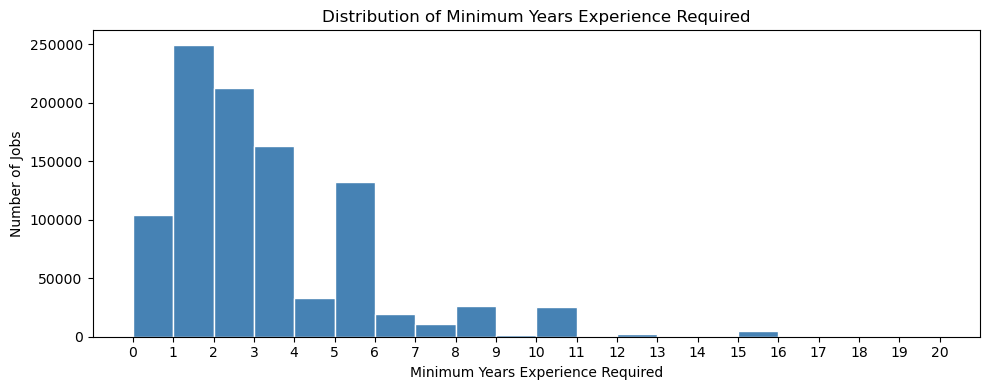

0    103672
1    249546
2    213059
3    163289
4     33448
5    132565
6     19107
7     10984
8     26468
9      1092
Name: minimumYearsExperience, dtype: int64


In [19]:
#WU5 — Distribution of minimumYearsExperience
exp_data = df_dedup['minimumYearsExperience'].dropna()
exp_data = exp_data[exp_data <= 20]  # Filter outliers

plt.figure(figsize=(10, 4))
plt.hist(exp_data, bins=range(0, 21), edgecolor='white', color='steelblue')
plt.xlabel('Minimum Years Experience Required')
plt.ylabel('Number of Jobs')
plt.title('Distribution of Minimum Years Experience Required')
plt.xticks(range(0, 21))
plt.tight_layout()
plt.show()

print(exp_data.value_counts().sort_index().head(10))


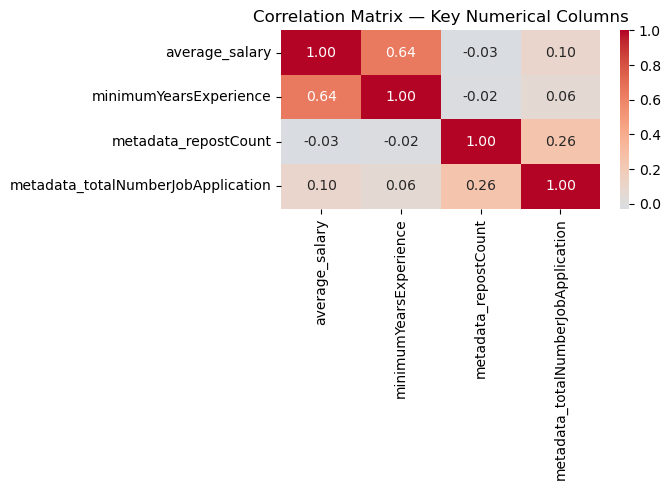

                                    average_salary  minimumYearsExperience  \
average_salary                            1.000000                0.640974   
minimumYearsExperience                    0.640974                1.000000   
metadata_repostCount                     -0.026491               -0.022404   
metadata_totalNumberJobApplication        0.096354                0.061191   

                                    metadata_repostCount  \
average_salary                                 -0.026491   
minimumYearsExperience                         -0.022404   
metadata_repostCount                            1.000000   
metadata_totalNumberJobApplication              0.255110   

                                    metadata_totalNumberJobApplication  
average_salary                                                0.096354  
minimumYearsExperience                                        0.061191  
metadata_repostCount                                          0.255110  
metadata_totalNu

In [20]:
#WU6 — Correlation Matrix
num_cols = ['average_salary', 'minimumYearsExperience',
            'metadata_repostCount', 'metadata_totalNumberJobApplication']
corr = df_dedup[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Key Numerical Columns')
plt.tight_layout()
plt.show()
print(corr)

Warm-Up Findings Summary
WU1 — Dataset Overview

1,048,585 rows, 22 columns, date range 2022-10-03 to 2024-05-29
Unique jobPostIds: 1,044,597; after composite key deduplication: 987,656

WU2 — Top Categories

Information Technology and Engineering tied at #1 (each ~8%), Admin/Secretarial third (6.6%)
Top 10 categories account for approximately 62% of all postings

WU3 — Salary by Position Level

Senior Management median: $9,500; Fresh/entry level lowest at $2,550
Clear salary ladder — each level up shows a meaningful jump

WU4 — Missing Values

occupationId is 100% null — can be safely ignored throughout analysis
Only 0.4% of rows (~3,988) have missing values in other columns — overall data quality is good

WU5 — Experience Distribution

Bulk concentrated at 1-3 years (~63% of postings)
0 years experience accounts for ~10%; notable spike at 5 years (13%) — likely an industry convention threshold

WU6 — Correlations

Strongest: salary vs experience (0.64) — more experience required, higher the pay
repostCount vs applications (0.26) — heavily reposted jobs attract slightly more applications, likely due to longer exposure time
All other pairs weak (< 0.15) — metrics are largely independent of each other

Part 2: Persona A — The Career Coach
Brief: Advise mid-career professionals switching into Tech, Healthcare, or Finance.

Questions
•	Q1: Salary distributions (box plots) across IT, Healthcare, Banking
•	Q2: Low barrier, high demand — scatter plot of categories by postings vs median experience
•	Q3: Fastest growing job titles within the three industries
•	Q4: Position level mix — can switchers enter at junior level?
•	Q5: Competition — applicants per vacancy and apply rate
•	Q6: Top 5 most-hired job titles per industry


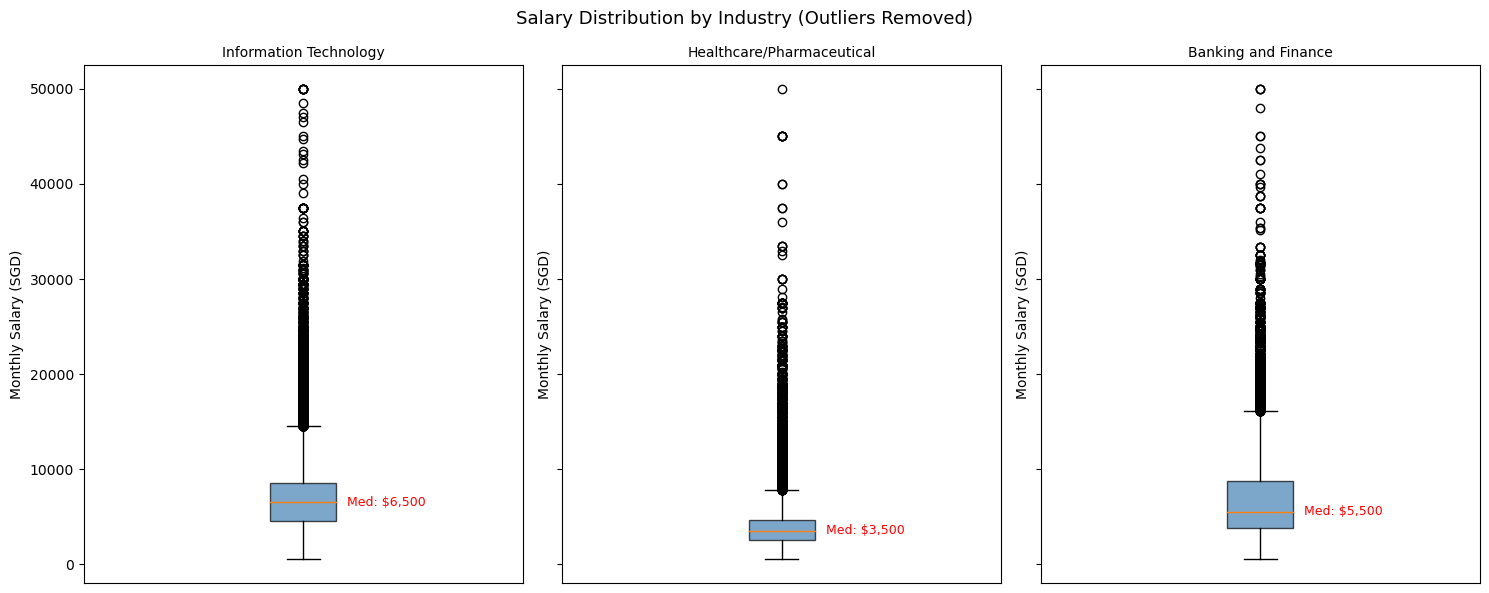

Information Technology:
  Median=6,500  P25=4,500  P75=8,500  n=133,916
Healthcare / Pharmaceutical:
  Median=3,500  P25=2,550  P75=4,650  n=50,925
Banking and Finance:
  Median=5,500  P25=3,850  P75=8,750  n=59,297


In [22]:
#Q1 — Salary Distribution (Box Plot)
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for ax, cat in zip(axes, TARGET_CATS):
    data = df_target[df_target['category'] == cat]['average_salary'].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax.set_title(cat.replace(' / ', '/'), fontsize=10)
    ax.set_ylabel('Monthly Salary (SGD)')
    ax.set_xticks([])  # 去掉x轴刻度
    med = np.median(data.to_numpy())
    ax.text(1.1, med, f'Med: ${med:,.0f}', va='center', fontsize=9, color='red')

plt.suptitle('Salary Distribution by Industry (Outliers Removed)', fontsize=13)
plt.tight_layout()
plt.show()

# NumPy stats table
for cat in TARGET_CATS:
    data = df_target[df_target['category'] == cat]['average_salary'].dropna().to_numpy()
    print(f'{cat}:')
    print(f'  Median={np.median(data):,.0f}  P25={np.percentile(data,25):,.0f}  P75={np.percentile(data,75):,.0f}  n={len(data):,}')

Q1 Finding: IT has the highest median salary at $6,500/month, followed by Banking at $5,500 and Healthcare at $3,500. All three industries show wide salary bands with significant upper outliers, indicating high earners exist in every sector. The IQR for IT ($4,500–$8,500) is the widest, reflecting greater pay variability.

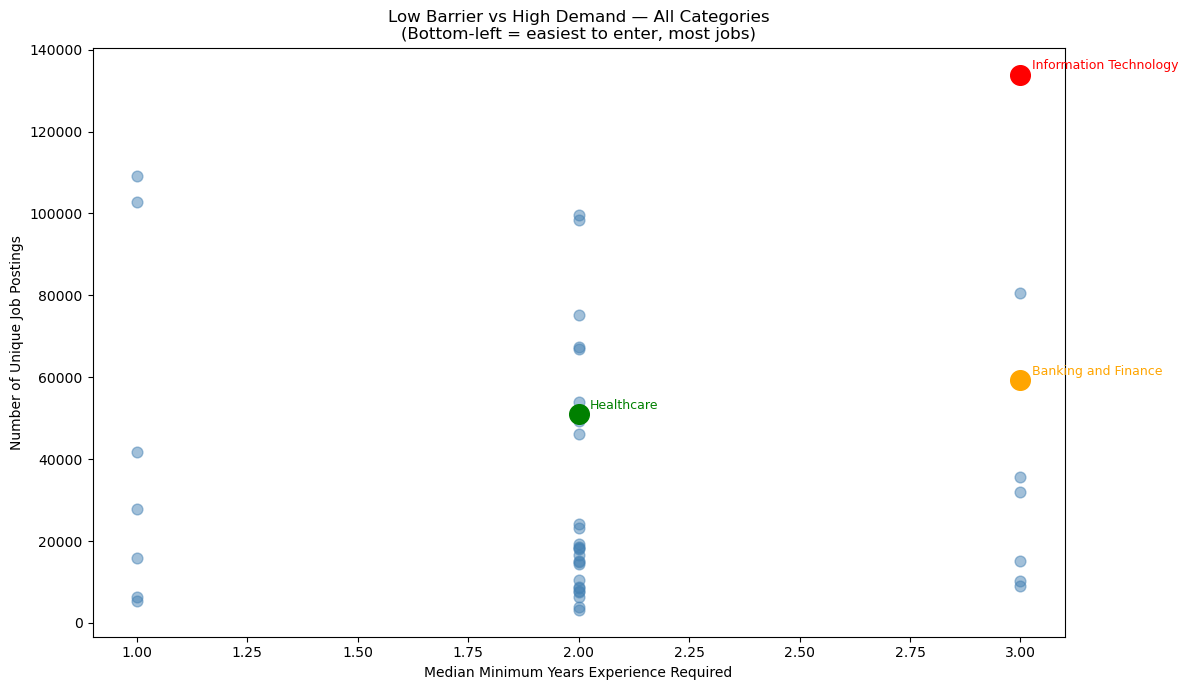

In [23]:
#Q2 — Low Barrier, High Demand Scatter Plot
# Compute stats per category across ALL categories (not just target 3)
cat_stats = (
    df_exploded
    .groupby('category')
    .agg(
        job_count=('metadata_jobPostId', 'nunique'),
        median_exp=('minimumYearsExperience', 'median')
    )
    .reset_index()
    .dropna()
)
# Filter to categories with at least 1000 jobs
cat_stats = cat_stats[cat_stats['job_count'] >= 1000]

plt.figure(figsize=(12, 7))
plt.scatter(cat_stats['median_exp'], cat_stats['job_count'],
            alpha=0.5, color='steelblue', s=60)

# Highlight target categories
colors = {'Information Technology': 'red',
          'Healthcare / Pharmaceutical': 'green',
          'Banking and Finance': 'orange'}
for cat, color in colors.items():
    row = cat_stats[cat_stats['category'] == cat]
    if not row.empty:
        plt.scatter(row['median_exp'], row['job_count'],
                    color=color, s=200, zorder=5)
        plt.annotate(cat.split(' / ')[0], 
                     (row['median_exp'].values[0], row['job_count'].values[0]),
                     textcoords='offset points', xytext=(8,4), fontsize=9, color=color)

plt.xlabel('Median Minimum Years Experience Required')
plt.ylabel('Number of Unique Job Postings')
plt.title('Low Barrier vs High Demand — All Categories\n(Bottom-left = easiest to enter, most jobs)')
plt.tight_layout()
plt.show()


Q2 Finding: Healthcare sits in the middle of the scatter plot — moderate job volume (~51K) with a median experience requirement of just 2 years, making it the most accessible of the three target industries. IT has the highest demand by far (~134K jobs) but requires 3 years median experience, placing it top-right. Banking similarly requires 3 years. Several non-target categories in the top-left quadrant (high volume, low experience) may also be worth exploring for career switchers.

                                    clean_title  first_count  last_count  total   growth_pct
5982                         accounts executive            3          35    851  1066.666667
55668                          project engineer            3          27    275   800.000000
24911                          dental assistant            5          44    323   780.000000
67890                  senior software engineer            5          43    741   760.000000
25838                           devops engineer            5          38    635   660.000000
62016                         security engineer            4          23    179   475.000000
67195                    senior project manager            3          17    225   466.666667
75397                        systems programmer            3          16    191   433.333333
76140                technical delivery manager            4          20    105   400.000000
81156  web developer & full-stack coding intern            5          

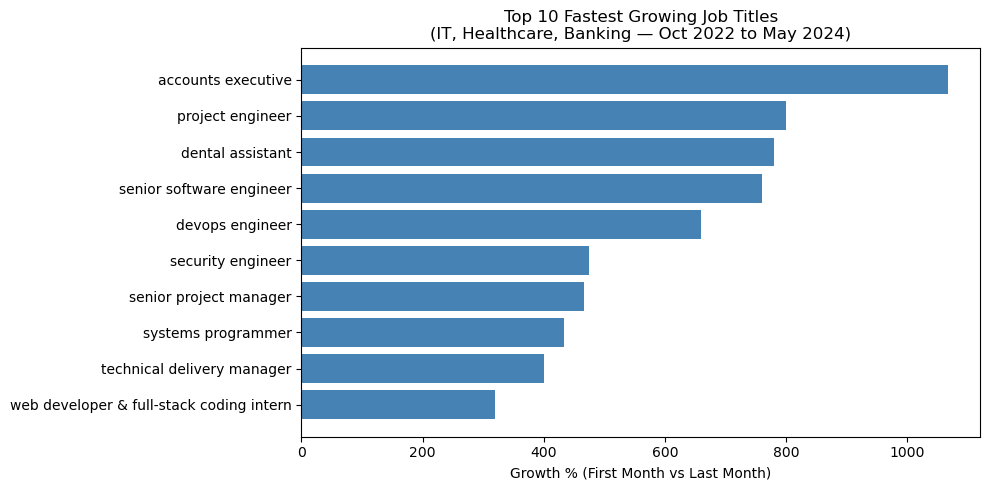

In [25]:
#Q3 — Fastest Growing Job Titles
import warnings
warnings.filterwarnings('ignore')

# Filter to target industries, clean titles
df_titles = df_target.copy()
df_titles['clean_title'] = (
    df_titles['title']
    .str.lower()
    .str.strip()
    .str.replace(r'\s*\(.*\)', '', regex=True)
    .str.strip()
)
df_titles['year_month'] = df_titles['metadata_originalPostingDate'].dt.to_period('M')

# Monthly counts per title
monthly_title = (
    df_titles
    .groupby(['clean_title', 'year_month'])
    .size()
    .reset_index(name='count')
)

# Get first and last month count per title
first_count = monthly_title.groupby('clean_title').first().reset_index()[['clean_title','count']].rename(columns={'count':'first_count'})
last_count  = monthly_title.groupby('clean_title').last().reset_index()[['clean_title','count']].rename(columns={'count':'last_count'})
total_count = monthly_title.groupby('clean_title')['count'].sum().reset_index().rename(columns={'count':'total'})

growth = first_count.merge(last_count, on='clean_title').merge(total_count, on='clean_title')
growth = growth[(growth['total'] >= 100) & (growth['first_count'] >= 3)]
growth = growth[growth['clean_title'].str.strip() != '']
growth['growth_pct'] = (growth['last_count'] - growth['first_count']) * 100.0 / growth['first_count']
growth = growth.sort_values('growth_pct', ascending=False).head(10)
print(growth[['clean_title','first_count','last_count','total','growth_pct']].to_string())

# Bar chart
plt.figure(figsize=(10, 5))
plt.barh(growth['clean_title'][::-1], growth['growth_pct'][::-1], color='steelblue')
plt.xlabel('Growth % (First Month vs Last Month)')
plt.title('Top 10 Fastest Growing Job Titles\n(IT, Healthcare, Banking — Oct 2022 to May 2024)')
plt.tight_layout()
plt.show()


Q3 Findings: Accounts Executive leads growth at +1,067%, driven by Banking demand. IT dominates the rest of the top 10 — Senior Software Engineer (+760%), DevOps Engineer (+660%), Project Engineer (+800%). Healthcare also shows up with Dental Assistant (+780%). This signals strong and broad demand growth across all three target industries over the 19-month period.

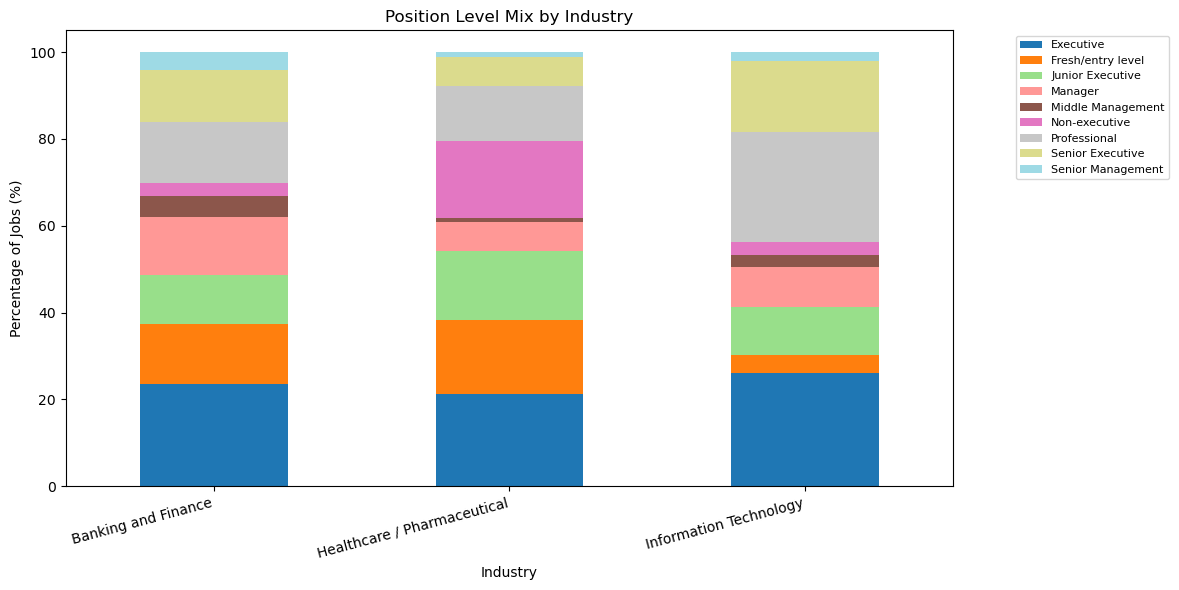

Information Technology: Fresh/entry = 4.2%
Healthcare / Pharmaceutical: Fresh/entry = 17.1%
Banking and Finance: Fresh/entry = 13.6%


In [26]:
#Q4 — Position Level Mix (Stacked Bar Chart)
level_counts = (
    df_target
    .dropna(subset=['positionLevels'])
    .groupby(['category', 'positionLevels'])
    .size()
    .reset_index(name='count')
)

# Pivot for stacked bar
level_pivot = level_counts.pivot(index='category', columns='positionLevels', values='count').fillna(0)
level_pct = level_pivot.div(level_pivot.sum(axis=1), axis=0) * 100

# Plot
level_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.xlabel('Industry')
plt.ylabel('Percentage of Jobs (%)')
plt.title('Position Level Mix by Industry')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=8)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Print Fresh/entry level % for each industry
for cat in TARGET_CATS:
    row = level_pct.loc[cat] if cat in level_pct.index else None
    if row is not None:
        entry = row.get('Fresh/entry level', 0)
        print(f'{cat}: Fresh/entry = {entry:.1f}%')


Q4 Findings: Healthcare has the highest proportion of Fresh/entry level roles at 17.1%, making it the most switcher-friendly industry. Banking follows at 13.6%. IT has only 4.2% Fresh/entry level — the vast majority of IT roles require Executive or Professional level experience, making cold-switching into IT extremely difficult without prior relevant experience.

                      category  applicants_per_vacancy  apply_rate_pct
0          Banking and Finance                     1.8             9.7
2       Information Technology                     1.3             9.1
1  Healthcare / Pharmaceutical                     0.5             7.4


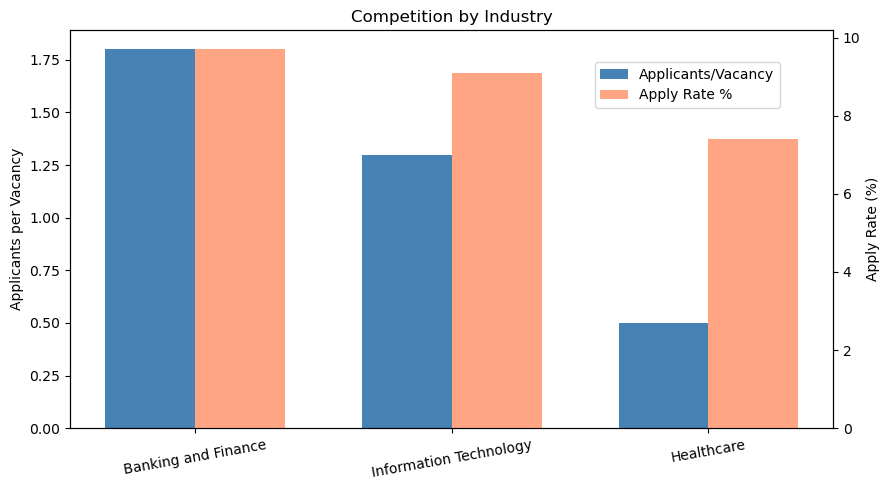

In [27]:
#Q5 — Competition Analysis
comp = (
    df_target
    [df_target['numberOfVacancies'] > 0]
    [df_target['metadata_totalNumberOfView'] > 0]
    .groupby('category')
    .agg(
        total_applications=('metadata_totalNumberJobApplication', 'sum'),
        total_vacancies=('numberOfVacancies', 'sum'),
        total_views=('metadata_totalNumberOfView', 'sum'),
        job_count=('metadata_jobPostId', 'count')
    )
    .reset_index()
)

comp['applicants_per_vacancy'] = (comp['total_applications'] / comp['total_vacancies']).round(1)
comp['apply_rate_pct'] = (comp['total_applications'] / comp['total_views'] * 100).round(1)
comp = comp.sort_values('applicants_per_vacancy', ascending=False)
print(comp[['category','applicants_per_vacancy','apply_rate_pct']].to_string())

# Grouped bar chart
x = np.arange(len(comp))
width = 0.35
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(x - width/2, comp['applicants_per_vacancy'], width, label='Applicants/Vacancy', color='steelblue')
ax1.set_ylabel('Applicants per Vacancy')
ax2 = ax1.twinx()
ax2.bar(x + width/2, comp['apply_rate_pct'], width, label='Apply Rate %', color='coral', alpha=0.7)
ax2.set_ylabel('Apply Rate (%)')
ax1.set_xticks(x)
ax1.set_xticklabels([c.split(' / ')[0] for c in comp['category']], rotation=10)
ax1.set_title('Competition by Industry')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()


Q5 Findings: Banking is the most competitive with 1.8 applicants per vacancy and a 9.7% apply rate. IT is in the middle at 1.3 applicants per vacancy. Healthcare is the least competitive at just 0.5 applicants per vacancy — but its low apply rate (7.4%) signals that low competition is driven by low desirability, not hidden opportunity.

                          category           clean_title  count
2476           Banking and Finance    accounts executive    804
12003          Banking and Finance       finance manager    603
19816          Banking and Finance  relationship manager    443
11841          Banking and Finance     finance executive    413
6534           Banking and Finance      business analyst    406
43591  Healthcare / Pharmaceutical           staff nurse   1455
30353  Healthcare / Pharmaceutical      clinic assistant   1030
33148  Healthcare / Pharmaceutical        enrolled nurse    656
34407  Healthcare / Pharmaceutical  healthcare assistant    323
32380  Healthcare / Pharmaceutical      dental assistant    322
81982       Information Technology     software engineer   2200
81652       Information Technology    software developer   1630
72794       Information Technology       project manager   1305
69395       Information Technology      network engineer   1145
51320       Information Technology      

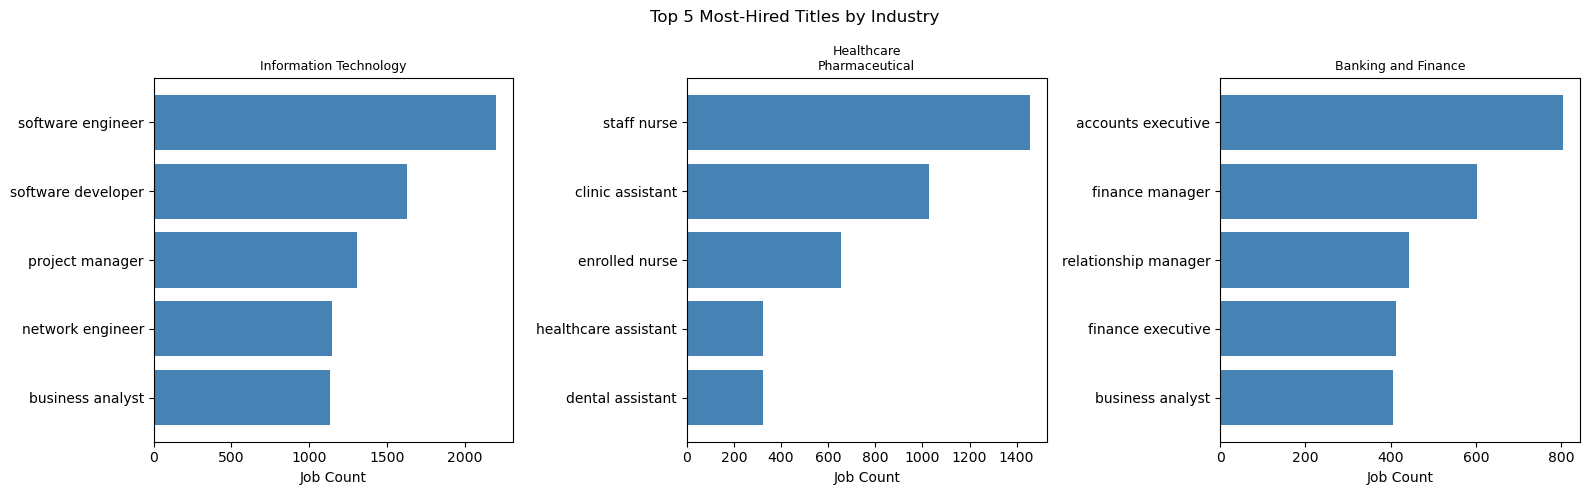

In [28]:
#Q6 — Top 5 Job Titles per Industry
top_titles = (
    df_target
    .assign(clean_title=lambda x: x['title'].str.lower().str.strip()
            .str.replace(r'\s*\(.*\)', '', regex=True).str.strip())
    .groupby(['category', 'clean_title'])
    .size()
    .reset_index(name='count')
    .sort_values(['category', 'count'], ascending=[True, False])
    .groupby('category')
    .head(5)
)
print(top_titles.to_string())

# Horizontal bar charts per industry
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cat in zip(axes, TARGET_CATS):
    data = top_titles[top_titles['category'] == cat].sort_values('count')
    ax.barh(data['clean_title'], data['count'], color='steelblue')
    ax.set_title(cat.replace(' / ','\n'), fontsize=9)
    ax.set_xlabel('Job Count')
plt.suptitle('Top 5 Most-Hired Titles by Industry', fontsize=12)
plt.tight_layout()
plt.show()



Q6 Finding: IT hiring is concentrated in software roles: Software Engineer, Software Developer, and Project Manager dominate. Healthcare hiring is clinically focused: Staff Nurse, Clinic Assistant, and Enrolled Nurse are the top three. Banking hiring centers on client-facing and finance roles: Accounts Executive, Finance Manager, and Relationship Manager. These title patterns give career switchers a concrete target to aim for when upskilling.